# Waveform Stacking for Totten Events

In [1]:
import os
from cryoquake import stream_handling as sh
from cryoquake import data_objects as do
from cryoquake import spatial_analysis as sa
from obspy.core.inventory import inventory
from obspy.core import Stream, Trace, read, UTCDateTime
import pandas as pd
from scipy.signal import correlate
import numpy as np
from scipy.cluster import hierarchy
from scipy.spatial import distance
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import fastcluster as fc
from plotly_resampler import FigureWidgetResampler
import plotly.graph_objects as go
import xarray as xr
from matplotlib.patches import Rectangle
from matplotlib.dates import DateFormatter, DayLocator, HourLocator

In [270]:
t1 = sh.UTCDateTime(2019,1,1)
t2 = sh.UTCDateTime(2019,1,3)


chunk = do.SeismicChunk(t1,t2)

root = Path.cwd()
w_path = root / "waveforms"
stack_path = root / "stacked_waveforms"
s_path = root / "stations"
c_path = root / "catalogues" / "all_stations"



inv_files = os.listdir(s_path)

inv = inventory.Inventory()

for file in inv_files:
    temp_path = os.path.join(s_path,file)
    inv += inventory.read_inventory(temp_path,level='response',format='STATIONXML')

inv = inv.select(station='TI?A',channel='CH?')

network_cat = do.EventCatalogue(t1,t2,c_path)


c_path = root / "catalogues" / "all_stations"

In [271]:
def collect_events(chunk, c_path, buffer, window_length):
    catalogue = do.EventCatalogue(chunk.starttime,chunk.endtime,c_path,templates=True)
    groups = catalogue.group_split()

    X_groups = {}
    X_sim = {}
    X_groups_len = {}

    for cluster_num, group_cat in groups.items():
        all_traces = []
        all_sim = []

        for event in group_cat:
            event_stream = chunk.stream.slice(event.starttime - buffer, event.starttime + window_length)
            all_traces.append(np.stack([tr.data for tr in event_stream],axis=0))
            all_sim.append(group_cat.attributes.loc[event.event_id]['similarity'])

        
        X = np.stack(all_traces,axis=1)
        X = X - X.mean(axis=2,keepdims=True)
        X_len = np.linalg.norm(X, axis=2, keepdims=True)
        X /= X_len


        if isinstance(X,np.ma.MaskedArray):
            X = X.filled(np.nan)

        if isinstance(X_len,np.ma.MaskedArray):
            X_len = X_len.filled(np.nan)

        X_sim[cluster_num] = np.array(all_sim)
        
        X_groups[cluster_num] = X
        X_groups_len[cluster_num] = X_len

    return X_groups, X_groups_len, X_sim


In [272]:
def collect_streams(chunk, c_path, buffer, window_length):
    catalogue = do.EventCatalogue(chunk.starttime,chunk.endtime,c_path,templates=True)
    groups = catalogue.group_split()

    X_groups = {}

    for cluster_num, group_cat in groups.items():
        all_streams = Stream()

        for event in group_cat:
            event_stream = chunk.stream.slice(event.starttime - buffer, event.starttime + window_length)
            all_streams += event_stream
        
        #X = np.stack(all_traces,axis=1)
        #X = X - X.mean(axis=2,keepdims=True)

        #if isinstance(X,np.ma.MaskedArray):
        #    X = X.filled(np.nan)
        
        X_groups[cluster_num] = all_streams

    return X_groups

In [286]:
chunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
chunk.decimate(5)
chunk.filter('bandpass',freqmin=1,freqmax=30) #relatively low high corner to help with correlation
stations = np.array([tr.id for tr in chunk.stream])
X_groups, X_groups_len, X_sim = collect_events(chunk,c_path,10,20)

In [402]:

t1 = sh.UTCDateTime(2018,12,24)
t2 = sh.UTCDateTime(2019,1,30)

chunk = do.SeismicChunk(t1,t2)
all_days = []
all_lens = []
all_sim = []
for daychunk in chunk:
    print('Slicing data for ' + str(daychunk.starttime.date))
    daychunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
    daychunk.decimate(5)
    daychunk.filter('bandpass',freqmin=3,freqmax=30) #relatively low high corner to help with correlation
    X_groups, X_groups_len, X_sim = collect_events(daychunk,c_path,10,20)
    all_days.append(X_groups)
    all_lens.append(X_groups_len)
    all_sim.append(X_sim)

Slicing data for 2018-12-24
Slicing data for 2018-12-25
Slicing data for 2018-12-26
Slicing data for 2018-12-27
Slicing data for 2018-12-28
Slicing data for 2018-12-29
Slicing data for 2018-12-30
Slicing data for 2018-12-31
Slicing data for 2019-01-01
Slicing data for 2019-01-02
Slicing data for 2019-01-03
Slicing data for 2019-01-04
Slicing data for 2019-01-05
Slicing data for 2019-01-06
Slicing data for 2019-01-07
Slicing data for 2019-01-08
Slicing data for 2019-01-09
Slicing data for 2019-01-10
Slicing data for 2019-01-11
Slicing data for 2019-01-12
Slicing data for 2019-01-13
Slicing data for 2019-01-14
Slicing data for 2019-01-15
Slicing data for 2019-01-16
Slicing data for 2019-01-17
Slicing data for 2019-01-18
Slicing data for 2019-01-19
Slicing data for 2019-01-20
Slicing data for 2019-01-21
Slicing data for 2019-01-22
Slicing data for 2019-01-23
Slicing data for 2019-01-24
Slicing data for 2019-01-25
Slicing data for 2019-01-26
Slicing data for 2019-01-27
Slicing data for 201

In [403]:
temp_cat = do.EventCatalogue(t1,t2,c_path,templates=True)
group_cats = temp_cat.group_split()

data_groups = {}
lens_groups = {}
sim_groups = {}
weights_groups = {}
stacks = {}

for clust_num in group_cats.keys():
    data = []
    lens = []
    sim = []
    for i, day in enumerate(all_days):
        if clust_num in day:
            data.append(day[clust_num])
            lens.append(all_lens[i][clust_num])
            sim.append(all_sim[i][clust_num])
    data = np.concat(data,axis=1)
    lens = np.concat(lens,axis=1)
    sim = np.concat(sim,axis=0)

    sort_ind = np.argsort(sim)

    data = data[:,sort_ind,:]
    lens = lens[:,sort_ind,0]
    sim = sim[sort_ind]
    weights = (sim - 0.5)*2

    data_groups[clust_num] = data
    lens_groups[clust_num] = lens
    sim_groups[clust_num] = sim
    weights_groups[clust_num] = weights

    stacks[clust_num] = np.nanmean(weights[None,:,None] * data,axis=1)


    #all_data = np.concat([day[clust_num] for day in all_days],axis=1)
    #stacked[clust_num] = np.nansum(all_data,axis=1)

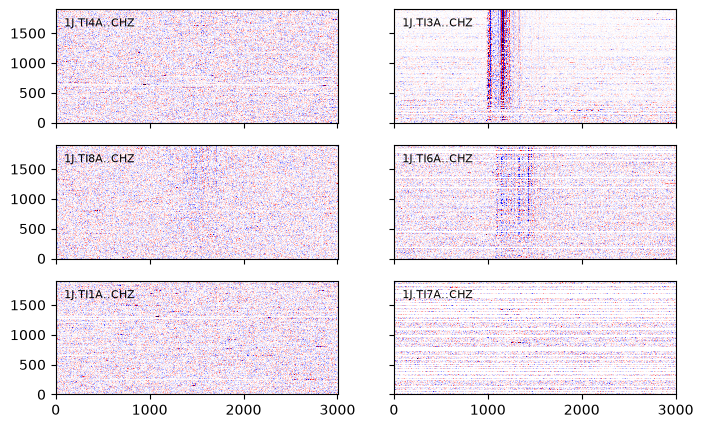

In [421]:
clust_num = 1309

fig, ax = plt.subplots(ncols=2,nrows=3,figsize=(8,5),sharex=True,sharey=True)
ax = ax.flatten()

for i in range(6):
    ax[i].pcolormesh(data_groups[clust_num][i,:,:],cmap='seismic',vmin=-0.2,vmax=0.2)
    ax[i].annotate(stations[i],(0.03,0.85),xycoords='axes fraction',fontsize=8)
    #ax[i].set_title(stations[i])

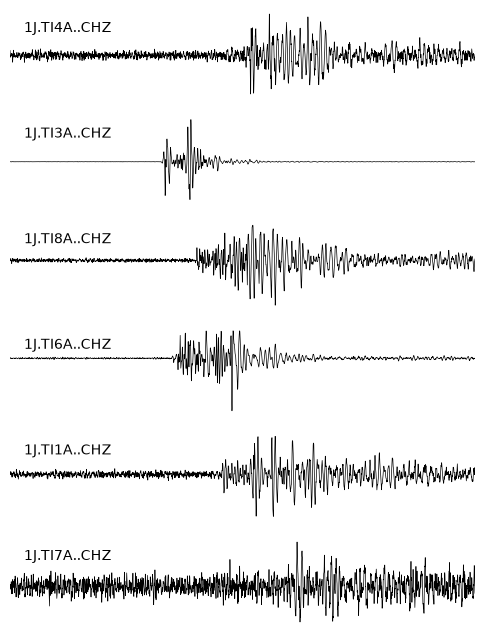

In [422]:
fig, ax = plt.subplots(ncols=1,nrows=6,figsize=(6,8))

for i in range(6):
    tr_i = stacks[clust_num][i,:]
    ax[i].plot(tr_i,lw=0.5,color='black')
    ax[i].annotate(stations[i],(0.03,0.75),xycoords='axes fraction')
    ax[i].set_xlim(0,3000)
    ax[i].set_axis_off()